In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time as t
import os 
import sys
import pandas as pd
print(f"imported at: {t.ctime()}")

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.rdMolDescriptors import CalcTPSA

# rdkitdraw
from rdkit.Chem import Draw
import py3Dmol as dmol
from rdkit.Chem import AllChem,Descriptors,Draw

from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs

imported at: Thu Feb 19 13:26:11 2026


    train_loss  test_loss        lr
0     1.218705   0.826834  0.000100
1     0.752536   0.694300  0.000100
2     0.652930   0.613750  0.000100
3     0.582856   0.553974  0.000100
4     0.523618   0.500583  0.000100
..         ...        ...       ...
95    0.142495   0.204393  0.000006
96    0.142334   0.204207  0.000003
97    0.141827   0.203841  0.000003
98    0.141659   0.204270  0.000003
99    0.141667   0.203945  0.000003

[100 rows x 3 columns]


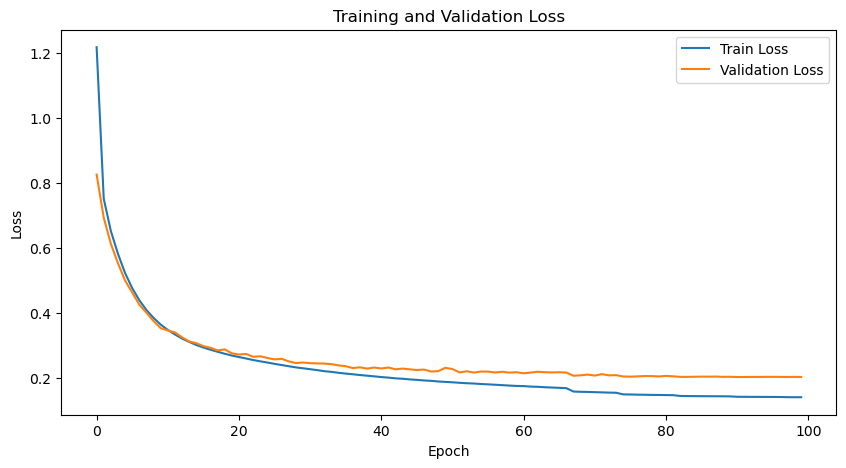

In [2]:
save_folder = "save/"
file = "history.csv"

df = pd.read_csv(save_folder + file)
print(df)

def plot_history(df:pd.DataFrame, save_folder:str, file:str):
    x = np.linspace(0, len(df)-1, len(df))
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['train_loss'], label='Train Loss')
    plt.plot(x, df['test_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')


    plt.savefig(save_folder + "history_plot.png")
    plt.show()


plot_history(df, save_folder, file)



In [21]:
resultant_path = 'CVAE_results.txt'

# first column is smiles,
# second column is: MW, third column is LogP

train_path = '250k_zinc_clean.txt'

def read_train_file(train_path:str):
    smiles_list = []
    properties_list = []
    
    with open(train_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) >= 3:
                smiles_list.append(parts[0])
                properties_list.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
    
    return smiles_list, properties_list

def read_resultant_file(resultant_path:str):
    """
    This file has column headers, so we need to skip the first line when reading the file.
    The first column is SMILES, the second column is MW, and the third column is LogP.
    
    """
    gen_smiles = []
    gen_properties = []
    
    with open(resultant_path, 'r') as file:
        first_line = True
        #for line in file:
        #    parts = line.strip().split()
        #    if first_line:
        #        first_line = False
        #        continue  # Skip the header line
        #    if len(parts) >= 3:
        #        gen_smiles.append(parts[0])
        #        gen_properties.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
        # just print all results:
        
        first_line = True
        for line in file:
            if first_line:
                first_line = False
                continue  # Skip the header line
            #print(line.strip())
            # split at ','
            parts = line.strip().split(',')
            if len(parts) >= 3:
                gen_smiles.append(parts[0])
                gen_properties.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
        
    return gen_smiles, gen_properties

smiles_list, properties_list = read_train_file(train_path)

df = pd.DataFrame({
    'smiles': smiles_list,
    'MW': [prop[0] for prop in properties_list],
    'LogP': [prop[1] for prop in properties_list]
})



gen_smiles, gen_prop = read_resultant_file(resultant_path)
gen_df = pd.DataFrame({
    'smiles': gen_smiles,
    'MW': [prop[0] for prop in gen_prop],
    'LogP': [prop[1] for prop in gen_prop]
})



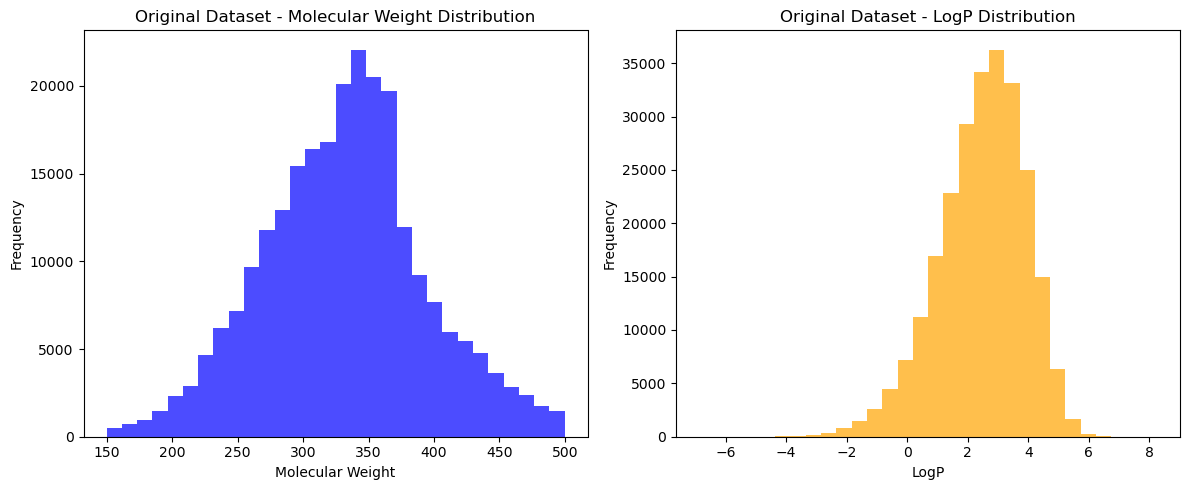

Generated Dataset:


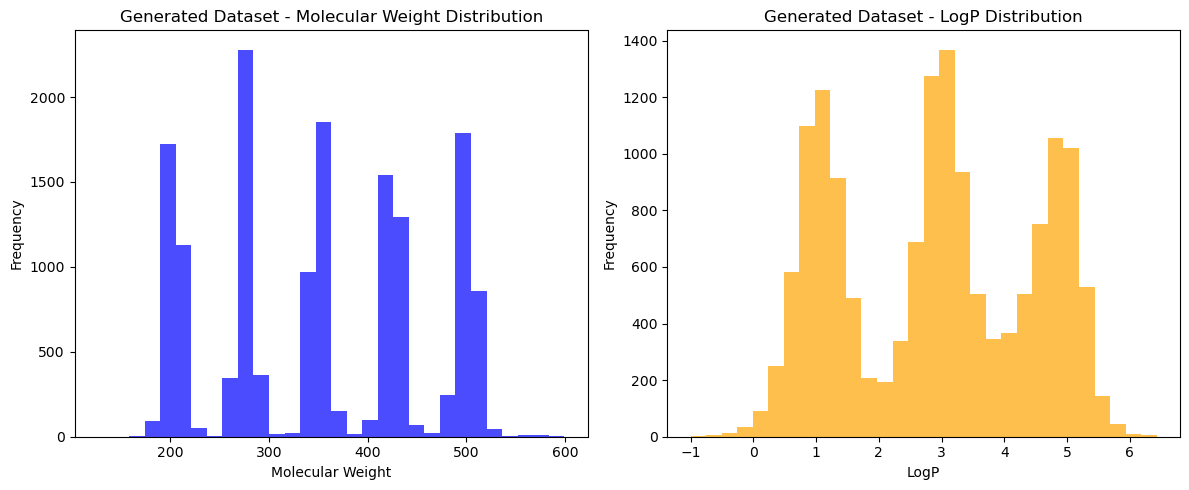

In [22]:
def plot_prop_distribution(df:pd.DataFrame, save_folder:str,top_title_str:str="Property Distribution"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(df['MW'], bins=30, alpha=0.7, color='blue')
    plt.title(top_title_str + ' - Molecular Weight Distribution')
    plt.xlabel('Molecular Weight')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(df['LogP'], bins=30, alpha=0.7, color='orange')
    plt.title(top_title_str + ' - LogP Distribution')
    plt.xlabel('LogP')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(save_folder + "property_distribution.png")
    plt.show()
plot_prop_distribution(df, save_folder, top_title_str="Original Dataset")
print(80*"=")
print("Generated Dataset:")
plot_prop_distribution(gen_df, save_folder, top_title_str="Generated Dataset")




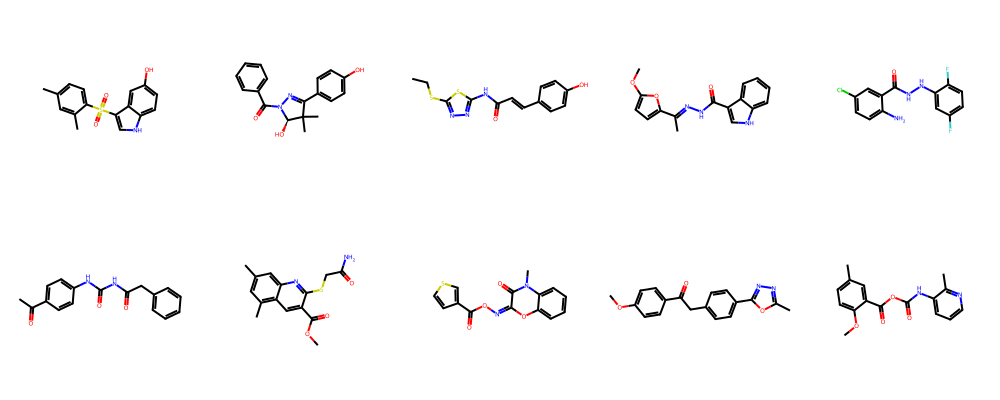

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

...

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

In [ ]:
# read molecules from file
# has columns: smiles, MW, LogP, TPSA
df = pd.read_csv("result.txt")



ms = [Chem.MolFromSmiles(s) for s in df['smiles']]
def avg_mv(mols):
    return sum([ExactMolWt(m) for m in mols])/len(mols)


samples = 10


def draw_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    img = Draw.MolsToGridImage(sample_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)



def draw_3d_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    for mol in sample_mols:
        # add hydrogens and embed the molecule in 3D space
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        # optimize the molecule
        # for better visualization
        AllChem.MMFFOptimizeMolecule(mol)
        view = dmol.view(width=400, height=400)
        view.addModel(Chem.MolToMolBlock(mol), 'sdf')
        view.setStyle({'stick': {}})
        view.zoomTo()
        display(view.show())


draw_samples(ms, samples)

draw_3d_samples(ms, samples)



In [ ]:


from rdkit.Chem.Scaffolds import MurckoScaffold
def load_mols_from_txt(file_path: str) -> tuple[list, list]:
    mols = []
    faulty_lines = []
    with open(file_path, 'r') as f:
        for line in f:
            smiles = line.strip()
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    mols.append(mol)
            except Exception:
                faulty_lines.append(smiles)
    return mols, faulty_lines


def load_as_df(file_path: str) -> pd.DataFrame:
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            smiles = line.strip()
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    mw = ExactMolWt(mol)
                    logp = MolLogP(mol)
                    tpsa = CalcTPSA(mol)
                    data.append({'smiles': smiles, 'MW': mw, 'LogP': logp, 'TPSA': tpsa})
            except Exception:
                continue
    df = pd.DataFrame(data)
    return df


def get_scaffold(mol: Chem.Mol) -> str:
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        # turn into smiles
        scaffold_smiles = Chem.MolToSmiles(scaffold,canonical=True)
        return scaffold_smiles
    except Exception as e:
        print(f"Error getting scaffold for molecule: {e}")
        return None

def get_unique_scaffolds(mols: list) -> set:
    scaffolds = set()
    for mol in mols:
        scaffold_smiles = get_scaffold(mol)
        if scaffold_smiles is not None:
            scaffolds.add(scaffold_smiles)
    return scaffolds


def df_with_scaffolds(df: pd.DataFrame) -> pd.DataFrame:
    df['scaffold'] = df['smiles'].apply(lambda s: get_scaffold(Chem.MolFromSmiles(s)))
    return df

def compute_morgan_fingerprint(mol: Chem.Mol, radius: int = 2, nBits: int = 2048) -> np.ndarray:
    from rdkit.Chem import AllChem
    
    fp_gen = Chem.rdMolDescriptors.GetMorganFingerprintAsBitVect
    fp = fp_gen(mol, radius, nBits=nBits)
    
    
    arr = np.zeros((nBits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def bulk_compute_fingerprints(mols: list, radius: int = 2, nBits: int = 2048) -> np.ndarray:
    fingerprints = []
    for mol in mols:
        fp = compute_morgan_fingerprint(mol, radius, nBits)
        fingerprints.append(fp)
    return np.array(fingerprints)

def bulk_tanimoto_similarity(mol: Chem.Mol, fps_ref: list) -> list:
    from sklearn.metrics import pairwise_distances
    # compute pairwise Tanimoto similarity
    # Tanimoto similarity is 1 - Jaccard distance
    #tanimoto_sim = 1 - pairwise_distances(fps_gen, fps_ref, metric='jaccard')

    fp_gen = compute_morgan_fingerprint(mol)
    # compute Tanimoto similarity to each reference fingerprint
    similarities = DataStructs.BulkTanimotoSimilarity(fp_gen, fps_ref)

    
    return similarities

def compute_similarity_to_reference(mols: list, ref_mols: list) -> list:
    """
    The goal of this function is to compute the Tanimoto simularity of each molecules -
    that have been genereated. Compared to the "reference" molecules.

    The reference molecules will be train and test set.....

    This will meassure how similar the generated molecules are to the training and test set.
    

    """
    # compute fingerprints for reference molecules
    fps_ref = bulk_compute_fingerprints(ref_mols)
    
    similarities = []
    for mol in mols:
        sim = bulk_tanimoto_similarity(mol, fps_ref)
        similarities.append(sim)
    return similarities

def append_similarity_to_df(df: pd.DataFrame, ref_mols: list) -> pd.DataFrame:
    df['similarity_to_ref'] = df['smiles'].apply(lambda s: compute_similarity_to_reference([Chem.MolFromSmiles(s)], ref_mols)[0])
    return df




